# Task 3: Heart Disease Prediction

## Objective
The goal of this task is to predict whether a person is at risk of heart disease based on medical attributes using machine learning classification models.

## Dataset
Heart Disease UCI Dataset (Kaggle)

## Skills Covered
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Binary classification
- Decision Tree modeling
- Model evaluation (Accuracy, ROC-AUC, Confusion Matrix)
- Feature importance analysis

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score)

df = pd.read_csv("heart_disease_uci.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


First 5 Rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal  

In [16]:
# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_10805/3776329273.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [17]:
# num = 0 --> No disease
# num > 0 --> Disease

df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print(df['num'].value_counts())

num
1    509
0    411
Name: count, dtype: int64


In [18]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())

   id  age  trestbps   chol    fbs  thalch  exang  oldpeak   ca  num  ...  \
0   1   63     145.0  233.0   True   150.0  False      2.3  0.0    0  ...   
1   2   67     160.0  286.0  False   108.0   True      1.5  3.0    1  ...   
2   3   67     120.0  229.0  False   129.0   True      2.6  2.0    1  ...   
3   4   37     130.0  250.0  False   187.0  False      3.5  0.0    0  ...   
4   5   41     130.0  204.0  False   172.0  False      1.4  0.0    0  ...   

   dataset_VA Long Beach  cp_atypical angina  cp_non-anginal  \
0                  False               False           False   
1                  False               False           False   
2                  False               False           False   
3                  False               False            True   
4                  False                True           False   

   cp_typical angina  restecg_normal  restecg_st-t abnormality  slope_flat  \
0               True           False                     False       False

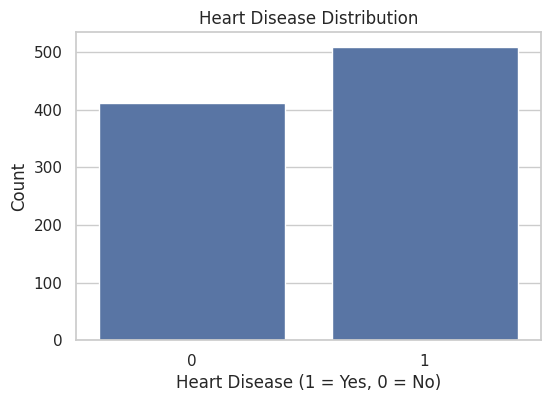

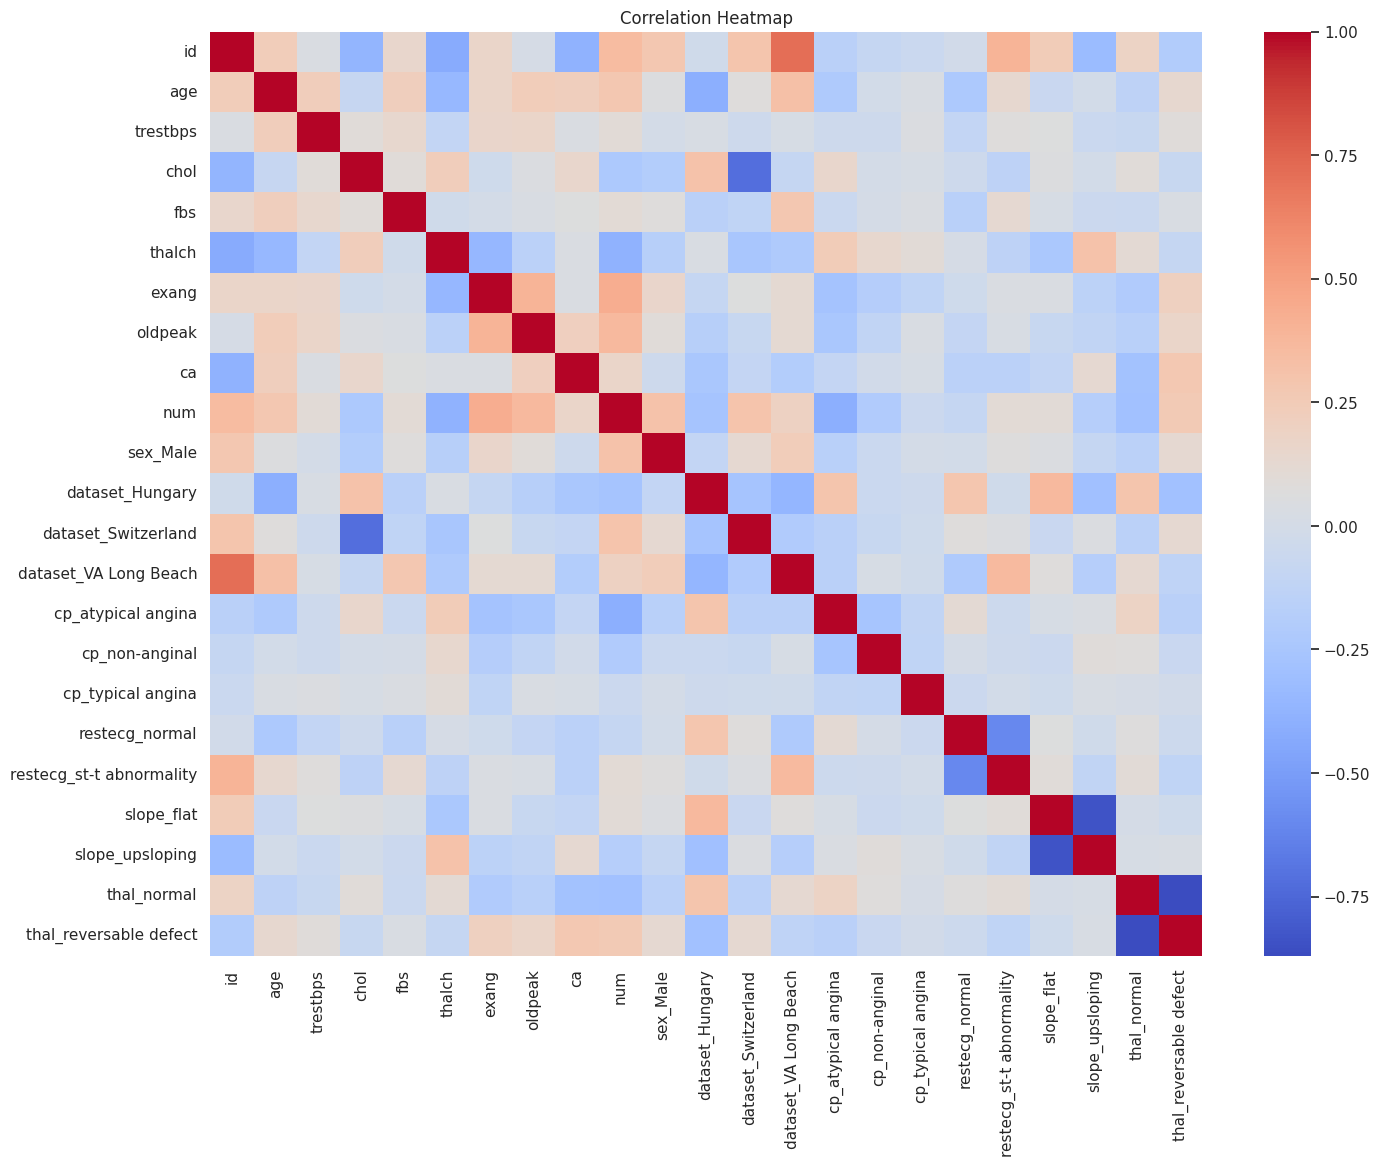

In [19]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

#H Correlation Heatmap
plt.figure(figsize=(16,12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [27]:
df = df.drop('id', axis=1)
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [28]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:")
print(f"{accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        75
           1       0.87      0.83      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



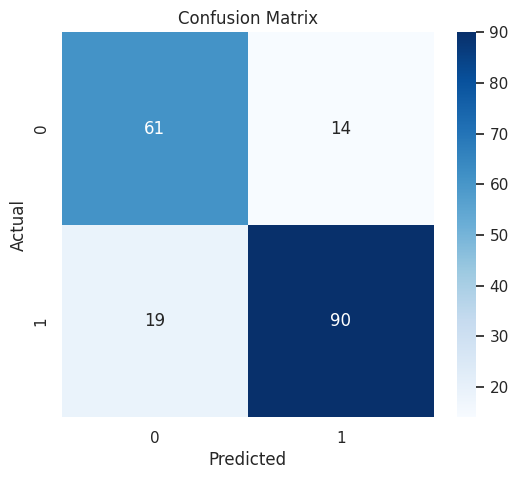

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

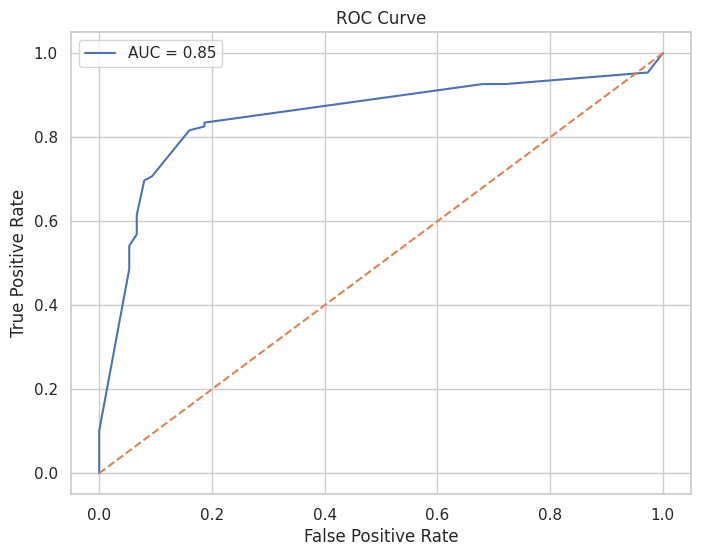

ROC-AUC Score: 0.85


In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print(f"ROC-AUC Score: {auc_score:.2f}")

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                  Feature  Importance
5                   exang    0.339221
2                    chol    0.190625
11  dataset_VA Long Beach    0.096599
7                      ca    0.091045
4                  thalch    0.066494
13         cp_non-anginal    0.039588
19            thal_normal    0.037816
8                sex_Male    0.034923
12     cp_atypical angina    0.031548
6                 oldpeak    0.028393


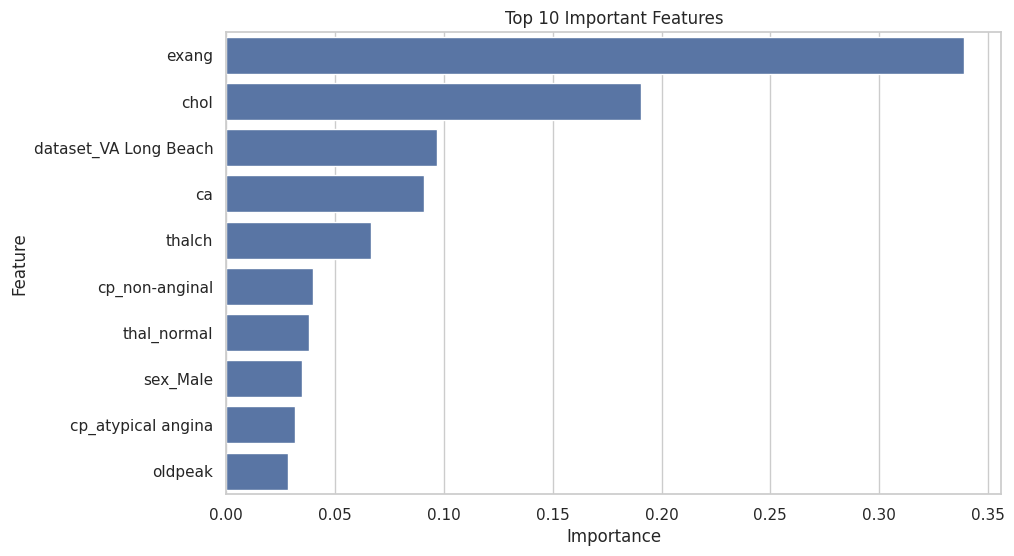

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()